# Подключение библиотек

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, precision_recall_curve, average_precision_score
)
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


# Загрузка данных

In [3]:
dataset = pd.read_csv("Data/s05-hw-dataset.csv")

## Анализ данных

In [4]:
dataset.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   client_id                       3000 non-null   int64  
 1   age                             3000 non-null   int64  
 2   income                          3000 non-null   int64  
 3   years_employed                  3000 non-null   int64  
 4   credit_score                    3000 non-null   int64  
 5   debt_to_income                  3000 non-null   float64
 6   num_credit_cards                3000 non-null   int64  
 7   num_late_payments               3000 non-null   int64  
 8   has_mortgage                    3000 non-null   int64  
 9   has_car_loan                    3000 non-null   int64  
 10  savings_balance                 3000 non-null   int64  
 11  checking_balance                3000 non-null   int64  
 12  region_risk_score               30

In [5]:
dataset.describe()


,client_id,age,income,years_employed,credit_score,debt_to_income,num_credit_cards,num_late_payments,has_mortgage,has_car_loan,savings_balance,checking_balance,region_risk_score,phone_calls_to_support_last_3m,active_loans,customer_tenure_years,default
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1500.500000,45.059667,69658.992000,19.577667,649.285333,0.284065,3.494667,6.869333,0.495000,0.501333,20607.256667,5559.684333,0.400175,9.524667,1.976333,6.968667,0.410333
std,866.169729,14.192883,24742.235182,11.381497,69.955852,0.161112,2.289917,4.291278,0.500058,0.500082,14035.209739,6306.032612,0.204529,5.779030,1.408700,4.349942,0.491976
min,1.000000,21.000000,15000.000000,0.000000,402.000000,0.006147,0.000000,0.000000,0.000000,0.000000,0.000000,-3000.000000,0.001148,0.000000,0.000000,0.000000,0.000000
25%,750.750000,33.000000,52641.750000,10.000000,604.000000,0.157796,1.000000,3.000000,0.000000,0.000000,9612.250000,341.500000,0.239208,5.000000,1.000000,3.000000,0.000000
50%,1500.500000,45.000000,69784.500000,20.000000,647.000000,0.261726,3.000000,7.000000,0.000000,1.000000,20021.000000,5114.500000,0.381992,10.000000,2.000000,7.000000,0.000000
75%,2250.250000,57.000000,85874.250000,29.000000,697.000000,0.388886,6.000000,10.000000,1.000000,1.000000,30101.250000,9906.250000,0.549213,15.000000,3.000000,11.000000,1.000000
max,3000.000000,69.000000,156351.000000,39.000000,850.000000,0.878343,7.000000,14.000000,1.000000,1.000000,75237.000000,29335.000000,0.961733,19.000000,4.000000,14.000000,1.000000


In [6]:
# Распределение целевого признака default
print("Распределение целевого признака 'default':")
print(dataset['default'].value_counts(normalize=True))
print("\nАбсолютные значения:")
print(dataset['default'].value_counts())


Распределение целевого признака 'default':
default
0    0.589667
1    0.410333
Name: proportion, dtype: float64

Абсолютные значения:
default
0    1769
1    1231
Name: count, dtype: int64


In [7]:
dataset.head(10)

,client_id,age,income,years_employed,credit_score,debt_to_income,num_credit_cards,num_late_payments,has_mortgage,has_car_loan,savings_balance,checking_balance,region_risk_score,phone_calls_to_support_last_3m,active_loans,customer_tenure_years,default
0,1,25,94074,22,839,0.547339,1,7,0,0,26057,5229,0.080052,19,1,8,0
1,2,58,51884,26,565,0.290882,1,1,0,1,16221,11595,0.428311,15,0,7,0
2,3,53,48656,39,561,0.522340,1,13,0,0,55448,-2947,0.770883,15,4,5,0
3,4,42,81492,30,582,0.709123,2,10,1,1,35188,17727,0.357619,0,2,7,1
4,5,42,94713,8,642,0.793392,3,3,0,0,0,-404,0.414260,17,1,10,1
5,6,63,71006,1,712,0.541594,3,0,0,0,14162,372,0.100423,12,0,13,0
6,7,25,37840,25,691,0.032334,1,12,0,0,56999,973,0.432156,12,2,1,0
7,8,55,35993,22,662,0.631521,0,0,0,1,5267,462,0.096401,6,4,2,0
8,9,30,34321,36,687,0.620856,0,7,1,1,20995,3650,0.632998,17,1,1,1
9,10,25,25809,23,601,0.254544,5,0,0,1,38464,3379,0.367238,10,3,0,0


# Базовая EDA

In [8]:
# Поиск аномальных значений методом IQR (Interquartile Range)
def find_outliers_iqr(df, column):
    """Находит выбросы в столбце используя метод IQR"""
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Выбираем числовые столбцы (исключаем client_id и default)
numeric_columns = dataset.select_dtypes(include=[np.number]).columns.tolist()
numeric_columns = [col for col in numeric_columns if col not in ['client_id', 'default']]

print("Поиск выбросов методом IQR:\n")
print("=" * 80)

outliers_summary = {}

for col in numeric_columns:
    outliers, lower_bound, upper_bound = find_outliers_iqr(dataset, col)
    num_outliers = len(outliers)
    outliers_summary[col] = {
        'count': num_outliers,
        'percentage': (num_outliers / len(dataset)) * 100,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound
    }
    print(f"\n{col}:")
    print(f"  Выбросов: {num_outliers} ({(num_outliers / len(dataset)) * 100:.2f}%)")
    print(f"  Границы: [{lower_bound:.2f}, {upper_bound:.2f}]")
    if num_outliers > 0 and num_outliers <= 20:  # Показываем примеры если их немного
        print(f"  Примеры выбросов: {outliers[col].tolist()[:10]}")


Поиск выбросов методом IQR:


age:
  Выбросов: 0 (0.00%)
  Границы: [-3.00, 93.00]

income:
  Выбросов: 18 (0.60%)
  Границы: [2793.00, 135723.00]
  Примеры выбросов: [142856, 140239, 141435, 137599, 140316, 139185, 135868, 146488, 145794, 136794]

years_employed:
  Выбросов: 0 (0.00%)
  Границы: [-18.50, 57.50]

credit_score:
  Выбросов: 25 (0.83%)
  Границы: [464.50, 836.50]

debt_to_income:
  Выбросов: 18 (0.60%)
  Границы: [-0.19, 0.74]
  Примеры выбросов: [0.7933920649976469, 0.7436724674741001, 0.7825201300352898, 0.7464343290038182, 0.7396797112388273, 0.8749381444376918, 0.8009372048627297, 0.7878038255176737, 0.878343349584274, 0.7967371234477475]

num_credit_cards:
  Выбросов: 0 (0.00%)
  Границы: [-6.50, 13.50]

num_late_payments:
  Выбросов: 0 (0.00%)
  Границы: [-7.50, 20.50]

has_mortgage:
  Выбросов: 0 (0.00%)
  Границы: [-1.50, 2.50]

has_car_loan:
  Выбросов: 0 (0.00%)
  Границы: [-1.50, 2.50]

savings_balance:
  Выбросов: 15 (0.50%)
  Границы: [-21121.25, 60834.75]
  

In [9]:
# Проверка на логические аномалии
print("Проверка на логические аномалии:\n")
print("=" * 80)

# Проверка отрицательных значений там, где их не должно быть
logical_checks = {
    'age': lambda x: (x < 18) | (x > 100),
    'income': lambda x: x < 0,
    'years_employed': lambda x: x < 0,
    'credit_score': lambda x: (x < 300) | (x > 850),
    'debt_to_income': lambda x: (x < 0) | (x > 1),
    'num_credit_cards': lambda x: x < 0,
    'num_late_payments': lambda x: x < 0,
    'savings_balance': lambda x: x < 0,
    'phone_calls_to_support_last_3m': lambda x: x < 0,
    'active_loans': lambda x: x < 0,
    'customer_tenure_years': lambda x: x < 0,
    'region_risk_score': lambda x: (x < 0) | (x > 1),
    'has_mortgage': lambda x: (x < 0) | (x > 1),
    'has_car_loan': lambda x: (x < 0) | (x > 1),
}

anomalies_found = False
for col, check_func in logical_checks.items():
    if col in dataset.columns:
        anomalies = dataset[check_func(dataset[col])]
        if len(anomalies) > 0:
            anomalies_found = True
            print(f"\n{col}: найдено {len(anomalies)} аномальных значений")
            print(f"  Примеры индексов: {anomalies.index.tolist()[:10]}")

if not anomalies_found:
    print("\nЛогических аномалий не обнаружено!")

# Проверка checking_balance (может быть отрицательным, но проверим экстремальные значения)
print(f"\n\nchecking_balance:")
print(f"  Минимальное значение: {dataset['checking_balance'].min()}")
print(f"  Максимальное значение: {dataset['checking_balance'].max()}")
print(f"  Отрицательных значений: {(dataset['checking_balance'] < 0).sum()}")


Проверка на логические аномалии:


Логических аномалий не обнаружено!


checking_balance:
  Минимальное значение: -3000
  Максимальное значение: 29335
  Отрицательных значений: 702


In [10]:
# Сводная таблица с информацией о выбросах
outliers_df = pd.DataFrame({
    'Признак': numeric_columns,
    'Выбросов (IQR)': [outliers_summary[col]['count'] for col in numeric_columns],
    '% выбросов (IQR)': [f"{outliers_summary[col]['percentage']:.2f}%" for col in numeric_columns],
})

print("Сводная таблица выбросов:")
print("=" * 80)
print(outliers_df.to_string(index=False))

# Сохранение таблицы
outliers_df.to_csv('artifacts/outliers_summary.csv', index=False, encoding='utf-8-sig')
print("\n\nТаблица сохранена в artifacts/outliers_summary.csv")


Сводная таблица выбросов:
                       Признак  Выбросов (IQR) % выбросов (IQR)
                           age               0            0.00%
                        income              18            0.60%
                years_employed               0            0.00%
                  credit_score              25            0.83%
                debt_to_income              18            0.60%
              num_credit_cards               0            0.00%
             num_late_payments               0            0.00%
                  has_mortgage               0            0.00%
                  has_car_loan               0            0.00%
               savings_balance              15            0.50%
              checking_balance               8            0.27%
             region_risk_score               0            0.00%
phone_calls_to_support_last_3m               0            0.00%
                  active_loans               0            0.00%
         custo

## Резюме наблюдений

**Размер датасета:**
- Количество объектов: 3000
- Количество признаков: 17 (включая целевой признак `default`)

**Аномалии:**
- Явных логических аномалий не обнаружено. Все значения находятся в допустимых пределах (возраст от 21 до 69 лет, кредитный рейтинг в диапазоне 402-850, и т.д.).
- Обнаружены статистические выбросы методом IQR в следующих признаках: `income` (18 выбросов, 0.60%), `credit_score` (25 выбросов, 0.83%), `debt_to_income` (18 выбросов, 0.60%), `savings_balance` (15 выбросов, 0.50%), `checking_balance` (8 выбросов, 0.27%). Эти выбросы являются экстремальными, но логически допустимыми значениями.

**Распределение целевого признака:**
- Класс 0 (нет дефолта): 1769 объектов (58.97%)
- Класс 1 (дефолт): 1231 объект (41.03%)
- Баланс классов: умеренно несбалансированный, но приемлемый для обучения модели без дополнительной балансировки.


## Подготовка признаков и таргета

In [11]:
# Таргет - столбец default
y = dataset['default'].copy()

# Признаки - все столбцы кроме client_id и default
X = dataset.drop(columns=['client_id', 'default']).copy()

print("Размерность данных:")
print(f"  X (признаки): {X.shape}")
print(f"  y (таргет): {y.shape}")
print(f"\nНазвания признаков ({len(X.columns)}):")
print(list(X.columns))


Размерность данных:
  X (признаки): (3000, 15)
  y (таргет): (3000,)

Названия признаков (15):
['age', 'income', 'years_employed', 'credit_score', 'debt_to_income', 'num_credit_cards', 'num_late_payments', 'has_mortgage', 'has_car_loan', 'savings_balance', 'checking_balance', 'region_risk_score', 'phone_calls_to_support_last_3m', 'active_loans', 'customer_tenure_years']


In [12]:
# Проверка типов данных признаков
print("Типы данных признаков:")
print(X.dtypes)
print("\nВсе признаки числовые:", all(pd.api.types.is_numeric_dtype(X[col]) for col in X.columns))

Типы данных признаков:
age                                 int64
income                              int64
years_employed                      int64
credit_score                        int64
debt_to_income                    float64
num_credit_cards                    int64
num_late_payments                   int64
has_mortgage                        int64
has_car_loan                        int64
savings_balance                     int64
checking_balance                    int64
region_risk_score                 float64
phone_calls_to_support_last_3m      int64
active_loans                        int64
customer_tenure_years               int64
dtype: object

Все признаки числовые: True


In [13]:
# Проверка диапазонов ключевых признаков
print("Проверка диапазонов признаков:\n")

# Проверка debt_to_income (должен быть в [0, 1])
debt_to_income_min = X['debt_to_income'].min()
debt_to_income_max = X['debt_to_income'].max()
print(f"debt_to_income: [{debt_to_income_min:.6f}, {debt_to_income_max:.6f}]")
if debt_to_income_min >= 0 and debt_to_income_max <= 1:
    print("   В допустимом диапазоне [0, 1]")
else:
    print("    Выходит за допустимый диапазон [0, 1]")

# Проверка region_risk_score (должен быть в [0, 1])
region_risk_min = X['region_risk_score'].min()
region_risk_max = X['region_risk_score'].max()
print(f"\nregion_risk_score: [{region_risk_min:.6f}, {region_risk_max:.6f}]")
if region_risk_min >= 0 and region_risk_max <= 1:
    print("   В допустимом диапазоне [0, 1]")
else:
    print("    Выходит за допустимый диапазон [0, 1]")

# Проверка бинарных признаков
binary_features = ['has_mortgage', 'has_car_loan']
print("\nБинарные признаки:")
for feature in binary_features:
    unique_values = sorted(X[feature].unique())
    print(f"  {feature}: уникальные значения {unique_values}")
    if set(unique_values).issubset({0, 1}):
        print("     Корректные бинарные значения")
    else:
        print("      Неожиданные значения")


Проверка диапазонов признаков:

debt_to_income: [0.006147, 0.878343]
   В допустимом диапазоне [0, 1]

region_risk_score: [0.001148, 0.961733]
   В допустимом диапазоне [0, 1]

Бинарные признаки:
  has_mortgage: уникальные значения [np.int64(0), np.int64(1)]
     Корректные бинарные значения
  has_car_loan: уникальные значения [np.int64(0), np.int64(1)]
     Корректные бинарные значения


In [14]:
# Проверка на пропущенные значения
print("Проверка на пропущенные значения:")
print(f"  Пропущенных значений в X: {X.isnull().sum().sum()}")
print(f"  Пропущенных значений в y: {y.isnull().sum()}")

if X.isnull().sum().sum() == 0 and y.isnull().sum() == 0:
    print("\n Пропущенных значений нет")
else:
    print("\n  Обнаружены пропущенные значения!")
    if X.isnull().sum().sum() > 0:
        print("\nПропущенные значения по признакам:")
        print(X.isnull().sum()[X.isnull().sum() > 0])


Проверка на пропущенные значения:
  Пропущенных значений в X: 0
  Пропущенных значений в y: 0

 Пропущенных значений нет


In [15]:
# Итоговая информация о подготовленных данных
print("=" * 80)
print("ИТОГОВАЯ ИНФОРМАЦИЯ О ПОДГОТОВЛЕННЫХ ДАННЫХ")
print("=" * 80)
print(f"\nМатрица признаков X:")
print(f"  Размерность: {X.shape}")
print(f"  Количество признаков: {X.shape[1]}")
print(f"  Типы данных: все числовые")

print(f"\nВектор таргета y:")
print(f"  Размерность: {y.shape}")
print(f"  Распределение классов:")
print(f"    Класс 0: {(y == 0).sum()} ({(y == 0).sum() / len(y) * 100:.2f}%)")
print(f"    Класс 1: {(y == 1).sum()} ({(y == 1).sum() / len(y) * 100:.2f}%)")

print(f"\n✓ Данные готовы к использованию для обучения модели")


ИТОГОВАЯ ИНФОРМАЦИЯ О ПОДГОТОВЛЕННЫХ ДАННЫХ

Матрица признаков X:
  Размерность: (3000, 15)
  Количество признаков: 15
  Типы данных: все числовые

Вектор таргета y:
  Размерность: (3000,)
  Распределение классов:
    Класс 0: 1769 (58.97%)
    Класс 1: 1231 (41.03%)

✓ Данные готовы к использованию для обучения модели


## Train/Test-сплит и бейзлайн-модель

In [16]:
# Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # Сохраняем баланс классов
)

print("Разделение данных:")
print(f"  Обучающая выборка: {X_train.shape[0]} объектов ({X_train.shape[0] / len(X) * 100:.1f}%)")
print(f"  Тестовая выборка: {X_test.shape[0]} объектов ({X_test.shape[0] / len(X) * 100:.1f}%)")
print(f"\nРаспределение классов в обучающей выборке:")
print(f"  Класс 0: {(y_train == 0).sum()} ({(y_train == 0).sum() / len(y_train) * 100:.2f}%)")
print(f"  Класс 1: {(y_train == 1).sum()} ({(y_train == 1).sum() / len(y_train) * 100:.2f}%)")
print(f"\nРаспределение классов в тестовой выборке:")
print(f"  Класс 0: {(y_test == 0).sum()} ({(y_test == 0).sum() / len(y_test) * 100:.2f}%)")
print(f"  Класс 1: {(y_test == 1).sum()} ({(y_test == 1).sum() / len(y_test) * 100:.2f}%)")


Разделение данных:
  Обучающая выборка: 2400 объектов (80.0%)
  Тестовая выборка: 600 объектов (20.0%)

Распределение классов в обучающей выборке:
  Класс 0: 1415 (58.96%)
  Класс 1: 985 (41.04%)

Распределение классов в тестовой выборке:
  Класс 0: 354 (59.00%)
  Класс 1: 246 (41.00%)


In [17]:
# Построение бейзлайн-модели на основе DummyClassifier
# Используем стратегию "most_frequent" - предсказывает самый частый класс
baseline_model = DummyClassifier(strategy="most_frequent", random_state=42)
baseline_model.fit(X_train, y_train)

# Определяем самый частый класс
most_frequent_class = y_train.value_counts().idxmax()
most_frequent_count = y_train.value_counts().max()

print("Бейзлайн-модель обучена")
print(f"Стратегия: 'most_frequent' - предсказывает самый частый класс")
print(f"Самый частый класс в обучающей выборке: {most_frequent_class} (встречается {most_frequent_count} раз из {len(y_train)})")


Бейзлайн-модель обучена
Стратегия: 'most_frequent' - предсказывает самый частый класс
Самый частый класс в обучающей выборке: 0 (встречается 1415 раз из 2400)


In [18]:
# Предсказания бейзлайн-модели
y_pred_baseline = baseline_model.predict(X_test)
y_pred_proba_baseline = baseline_model.predict_proba(X_test)[:, 1]  # Вероятности класса 1

print("Примеры предсказаний бейзлайн-модели:")
print(f"  Первые 10 предсказаний: {y_pred_baseline[:10]}")
print(f"  Уникальные предсказания: {np.unique(y_pred_baseline)}")
print(f"\nПримеры вероятностей (первые 5):")
for i in range(5):
    print(f"  Объект {i}: вероятность класса 1 = {y_pred_proba_baseline[i]:.4f}")


Примеры предсказаний бейзлайн-модели:
  Первые 10 предсказаний: [0 0 0 0 0 0 0 0 0 0]
  Уникальные предсказания: [0]

Примеры вероятностей (первые 5):
  Объект 0: вероятность класса 1 = 0.0000
  Объект 1: вероятность класса 1 = 0.0000
  Объект 2: вероятность класса 1 = 0.0000
  Объект 3: вероятность класса 1 = 0.0000
  Объект 4: вероятность класса 1 = 0.0000


In [19]:
# Оценка бейзлайн-модели по метрикам
accuracy_baseline = accuracy_score(y_test, y_pred_baseline)
roc_auc_baseline = roc_auc_score(y_test, y_pred_proba_baseline)

print("=" * 80)
print("МЕТРИКИ БЕЙЗЛАЙН-МОДЕЛИ НА ТЕСТОВОЙ ВЫБОРКЕ")
print("=" * 80)
print(f"\nAccuracy: {accuracy_baseline:.4f} ({accuracy_baseline * 100:.2f}%)")
print(f"ROC-AUC: {roc_auc_baseline:.4f}")
print("\n" + "=" * 80)


МЕТРИКИ БЕЙЗЛАЙН-МОДЕЛИ НА ТЕСТОВОЙ ВЫБОРКЕ

Accuracy: 0.5900 (59.00%)
ROC-AUC: 0.5000



### Комментарии к бейзлайн-модели

**Что делает бейзлайн-модель:**
- Бейзлайн-модель с стратегией `"most_frequent"` всегда предсказывает самый частый класс в обучающей выборке (в нашем случае - класс 0, "нет дефолта").
- Это самая простая модель, которая не использует никаких признаков для предсказания.

**Почему важна точка отсчёта:**
1. **Минимальный порог качества**: Любая реальная модель должна превосходить бейзлайн. Если модель хуже бейзлайна, значит она работает некорректно.
2. **Оценка сложности задачи**: Высокий accuracy бейзлайна (≈58.97%) показывает, что задача умеренно сложная - простое правило "всегда предсказывать класс 0" уже даёт неплохой результат.
3. **Контекст для интерпретации метрик**: ROC-AUC бейзлайна ≈ 0.5 (случайное угадывание), что ожидаемо для модели, которая всегда предсказывает один класс. Реальная модель должна значительно превосходить это значение.
4. **Валидация подхода**: Сравнение с бейзлайном помогает убедиться, что используемые признаки действительно несут полезную информацию для предсказания.


## Логистическая регрессия и подбор гиперпараметров

In [20]:
# Построение Pipeline с StandardScaler и LogisticRegression
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000, random_state=42))
])

print("Pipeline создан:")
print(pipe)


Pipeline создан:
Pipeline(steps=[('scaler', StandardScaler()),
                ('logreg', LogisticRegression(max_iter=1000, random_state=42))])


In [21]:
# Подбор параметра C с помощью GridSearchCV
param_grid = {
    'logreg__C': [0.01, 0.1, 1.0, 10.0, 100.0]
}

grid_search = GridSearchCV(
    pipe, 
    param_grid, 
    cv=5, 
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print("Начало подбора гиперпараметров...")
grid_search.fit(X_train, y_train)

print("\nПодбор завершён!")
print(f"Лучший параметр C: {grid_search.best_params_['logreg__C']}")
print(f"Лучший ROC-AUC на кросс-валидации: {grid_search.best_score_:.4f}")


Начало подбора гиперпараметров...
Fitting 5 folds for each of 5 candidates, totalling 25 fits



Подбор завершён!
Лучший параметр C: 100.0
Лучший ROC-AUC на кросс-валидации: 0.8607


In [22]:
# Результаты подбора параметров
results_df = pd.DataFrame(grid_search.cv_results_)
print("Результаты подбора параметров:")
print("=" * 80)
for idx, row in results_df.iterrows():
    c_value = row['param_logreg__C']
    mean_score = row['mean_test_score']
    std_score = row['std_test_score']
    print(f"C = {c_value:6.2f}: ROC-AUC = {mean_score:.4f} (+/- {std_score * 2:.4f})")
print("=" * 80)


Результаты подбора параметров:
C =   0.01: ROC-AUC = 0.8603 (+/- 0.0187)
C =   0.10: ROC-AUC = 0.8606 (+/- 0.0181)
C =   1.00: ROC-AUC = 0.8607 (+/- 0.0179)
C =  10.00: ROC-AUC = 0.8607 (+/- 0.0180)
C = 100.00: ROC-AUC = 0.8607 (+/- 0.0180)


In [23]:
# Получение лучшей модели
best_model = grid_search.best_estimator_

# Предсказания на тестовой выборке
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

print("Предсказания получены для тестовой выборки")


Предсказания получены для тестовой выборки


In [24]:
# Оценка модели по метрикам
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("=" * 80)
print("МЕТРИКИ ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ НА ТЕСТОВОЙ ВЫБОРКЕ")
print("=" * 80)
print(f"\nAccuracy:  {accuracy:.4f} ({accuracy * 100:.2f}%)")
print(f"ROC-AUC:   {roc_auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

print("\nМатрица ошибок (Confusion Matrix):")
print(conf_matrix)
print("\n" + "=" * 80)


МЕТРИКИ ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ НА ТЕСТОВОЙ ВЫБОРКЕ

Accuracy:  0.8017 (80.17%)
ROC-AUC:   0.8756
Precision: 0.7953
Recall:    0.6951
F1-score:  0.7419

Матрица ошибок (Confusion Matrix):
[[310  44]
 [ 75 171]]



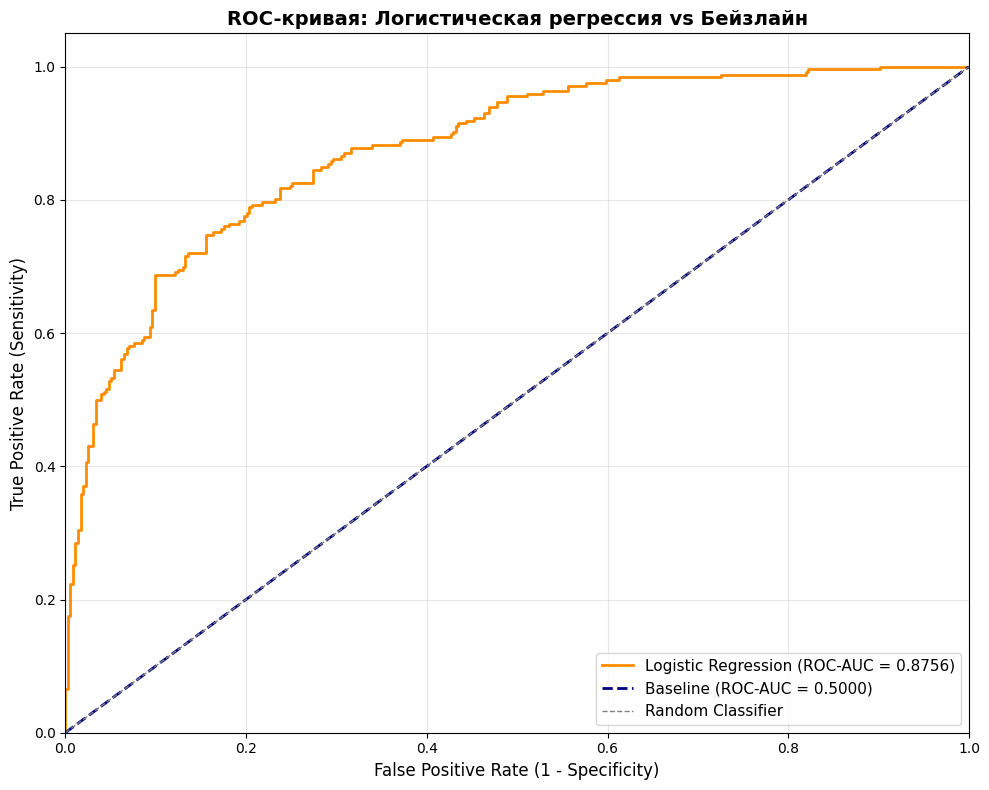

ROC-кривая сохранена в figures/roc_curve.png


In [25]:
# Построение ROC-кривой
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc_value = roc_auc_score(y_test, y_pred_proba)

# ROC-кривая для бейзлайна
fpr_baseline, tpr_baseline, _ = roc_curve(y_test, y_pred_proba_baseline)
roc_auc_baseline = roc_auc_score(y_test, y_pred_proba_baseline)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'Logistic Regression (ROC-AUC = {roc_auc_value:.4f})')
plt.plot(fpr_baseline, tpr_baseline, color='navy', lw=2, linestyle='--',
         label=f'Baseline (ROC-AUC = {roc_auc_baseline:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('ROC-кривая: Логистическая регрессия vs Бейзлайн', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print("ROC-кривая сохранена в figures/roc_curve.png")


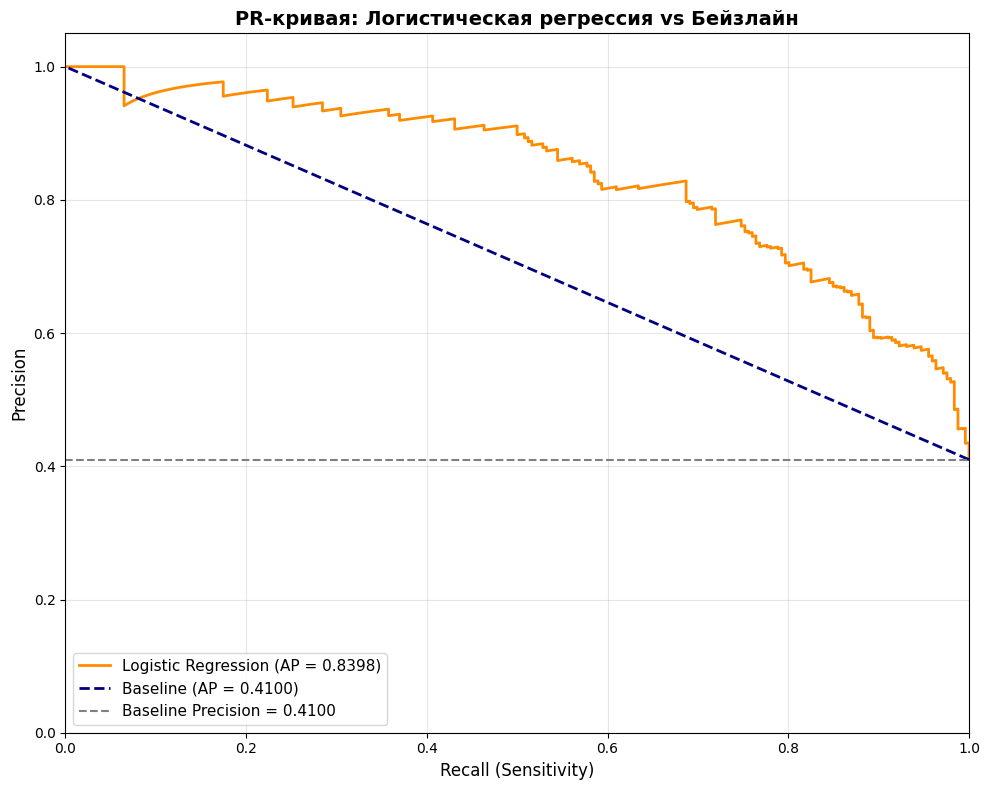

PR-кривая сохранена в figures/pr_curve.png

AVERAGE PRECISION SCORE
Average Precision (Logistic Regression): 0.8398
Average Precision (Baseline):            0.4100

Average Precision Score показывает среднее значение precision при всех возможных порогах recall.
Чем выше значение, тем лучше модель. Значение 0.8398 указывает на хорошее качество модели.


In [28]:
# Построение PR-кривой (Precision-Recall)
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba)
avg_precision = average_precision_score(y_test, y_pred_proba)

# PR-кривая для бейзлайна
precision_baseline, recall_baseline, _ = precision_recall_curve(y_test, y_pred_proba_baseline)
avg_precision_baseline = average_precision_score(y_test, y_pred_proba_baseline)

plt.figure(figsize=(10, 8))
plt.plot(recall_vals, precision_vals, color='darkorange', lw=2,
         label=f'Logistic Regression (AP = {avg_precision:.4f})')
plt.plot(recall_baseline, precision_baseline, color='navy', lw=2, linestyle='--',
         label=f'Baseline (AP = {avg_precision_baseline:.4f})')
# Горизонтальная линия - baseline precision (доля положительного класса)
baseline_precision = (y_test == 1).sum() / len(y_test)
plt.axhline(y=baseline_precision, color='gray', linestyle='--', 
            label=f'Baseline Precision = {baseline_precision:.4f}')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall (Sensitivity)', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('PR-кривая: Логистическая регрессия vs Бейзлайн', fontsize=14, fontweight='bold')
plt.legend(loc="lower left", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print("PR-кривая сохранена в figures/pr_curve.png")

# Явный вывод Average Precision Score
print("\n" + "=" * 80)
print("AVERAGE PRECISION SCORE")
print("=" * 80)
print(f"Average Precision (Logistic Regression): {avg_precision:.4f}")
print(f"Average Precision (Baseline):            {avg_precision_baseline:.4f}")
print(f"\nAverage Precision Score показывает среднее значение precision при всех возможных порогах recall.")
print(f"Чем выше значение, тем лучше модель. Значение {avg_precision:.4f} указывает на хорошее качество модели.")
print("=" * 80)


In [ ]:
# Анализ метрик для разных порогов вероятности
_, _, thresholds = precision_recall_curve(y_test, y_pred_proba)
precision_curve = precision_vals
recall_curve = recall_vals

# Вычисляем F1-score для каждого порога
f1_scores = 2 * (precision_curve * recall_curve) / (precision_curve + recall_curve + 1e-10)

# Находим оптимальный порог по F1-score
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
optimal_precision = precision_curve[optimal_idx]
optimal_recall = recall_curve[optimal_idx]
optimal_f1 = f1_scores[optimal_idx]

# Метрики для порога по умолчанию (0.5)
default_threshold = 0.5
default_precision = precision
default_recall = recall
default_f1 = f1

print("=" * 80)
print("АНАЛИЗ МЕТРИК ДЛЯ РАЗНЫХ ПОРОГОВ ВЕРОЯТНОСТИ")
print("=" * 80)

print(f"\n Порог по умолчанию (0.5):")
print(f"   Precision: {default_precision:.4f}")
print(f"   Recall:    {default_recall:.4f}")
print(f"   F1-score:  {default_f1:.4f}")

print(f"\n Оптимальный порог по F1-score: {optimal_threshold:.4f}")
print(f"   Precision: {optimal_precision:.4f}")
print(f"   Recall:    {optimal_recall:.4f}")
print(f"   F1-score:  {optimal_f1:.4f}")

# Предсказания с оптимальным порогом
y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)
optimal_accuracy = accuracy_score(y_test, y_pred_optimal)
optimal_conf_matrix = confusion_matrix(y_test, y_pred_optimal)

print(f"\n Accuracy с оптимальным порогом: {optimal_accuracy:.4f}")
print(f"\nМатрица ошибок с оптимальным порогом:")
print(optimal_conf_matrix)

print("\n" + "=" * 80)



АНАЛИЗ МЕТРИК ДЛЯ РАЗНЫХ ПОРОГОВ ВЕРОЯТНОСТИ

 Порог по умолчанию (0.5):
   Precision: 0.7953
   Recall:    0.6951
   F1-score:  0.7419

 Оптимальный порог по F1-score: 0.4407
   Precision: 0.7699
   Recall:    0.7480
   F1-score:  0.7588

 Accuracy с оптимальным порогом: 0.8050

Матрица ошибок с оптимальным порогом:
[[299  55]
 [ 62 184]]



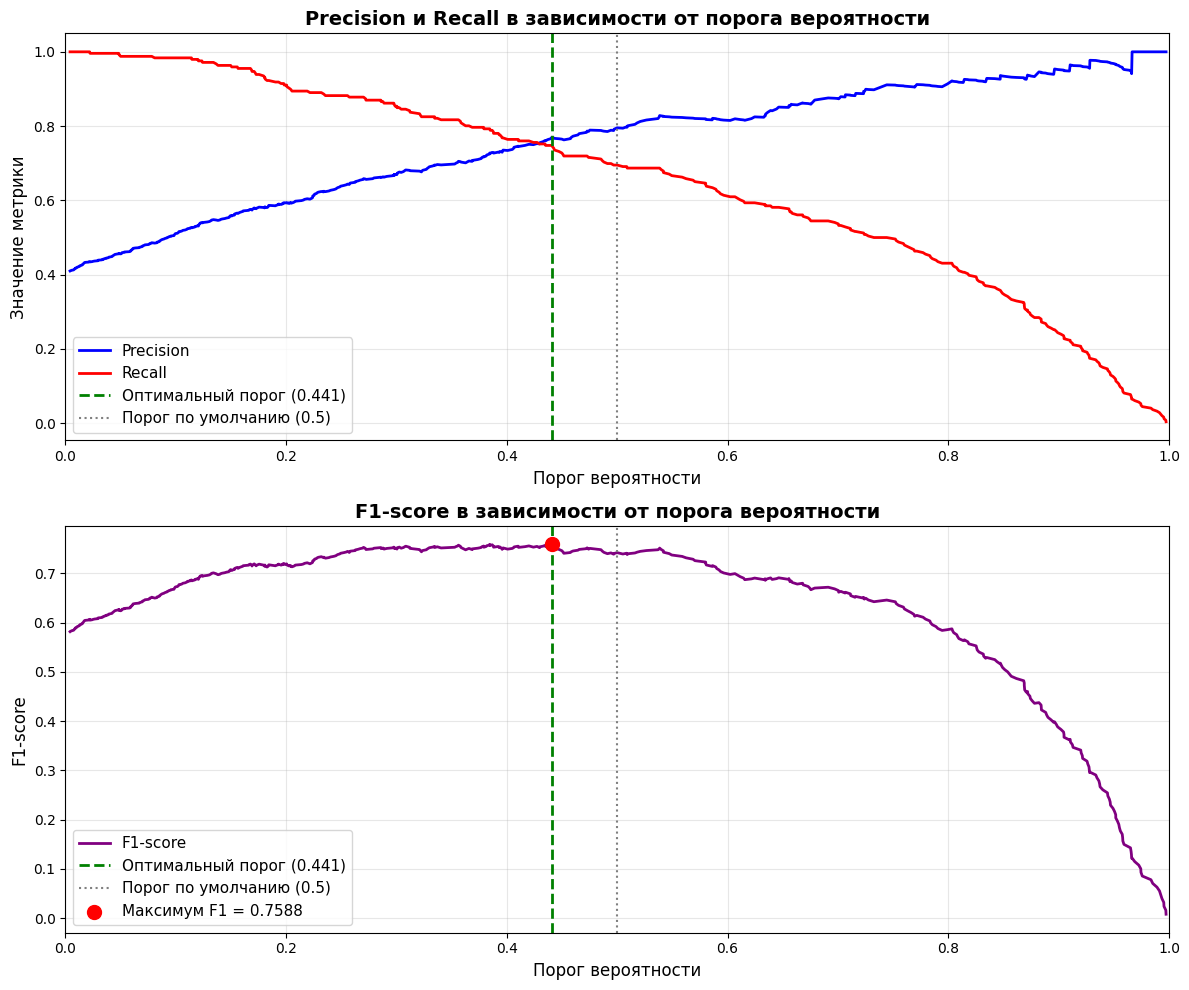

График зависимости метрик от порога сохранён в figures/metrics_vs_threshold.png


In [30]:
# Визуализация зависимости метрик от порога вероятности
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# График 1: Precision и Recall в зависимости от порога
axes[0].plot(thresholds, precision_curve[:-1], 'b-', label='Precision', linewidth=2)
axes[0].plot(thresholds, recall_curve[:-1], 'r-', label='Recall', linewidth=2)
axes[0].axvline(x=optimal_threshold, color='g', linestyle='--', linewidth=2, 
                label=f'Оптимальный порог ({optimal_threshold:.3f})')
axes[0].axvline(x=0.5, color='gray', linestyle=':', linewidth=1.5, 
                label='Порог по умолчанию (0.5)')
axes[0].set_xlabel('Порог вероятности', fontsize=12)
axes[0].set_ylabel('Значение метрики', fontsize=12)
axes[0].set_title('Precision и Recall в зависимости от порога вероятности', 
                  fontsize=14, fontweight='bold')
axes[0].legend(loc='best', fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([0, 1])

# График 2: F1-score в зависимости от порога
axes[1].plot(thresholds, f1_scores[:-1], 'purple', label='F1-score', linewidth=2)
axes[1].axvline(x=optimal_threshold, color='g', linestyle='--', linewidth=2, 
                label=f'Оптимальный порог ({optimal_threshold:.3f})')
axes[1].axvline(x=0.5, color='gray', linestyle=':', linewidth=1.5, 
                label='Порог по умолчанию (0.5)')
axes[1].scatter([optimal_threshold], [optimal_f1], color='red', s=100, zorder=5,
                label=f'Максимум F1 = {optimal_f1:.4f}')
axes[1].set_xlabel('Порог вероятности', fontsize=12)
axes[1].set_ylabel('F1-score', fontsize=12)
axes[1].set_title('F1-score в зависимости от порога вероятности', 
                  fontsize=14, fontweight='bold')
axes[1].legend(loc='best', fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0, 1])

plt.tight_layout()
plt.savefig('figures/metrics_vs_threshold.png', dpi=150, bbox_inches='tight')
plt.show()

print("График зависимости метрик от порога сохранён в figures/metrics_vs_threshold.png")



### Интерпретация метрик для выбранного порога

**Метрики для порога по умолчанию (0.5):**
- **Precision (0.7953)**: Из всех предсказанных дефолтов 79.53% действительно являются дефолтами. Это означает, что модель достаточно точна в своих предсказаниях положительного класса.
- **Recall (0.6951)**: Модель находит 69.51% всех реальных дефолтов. Это показывает, что около 30% дефолтов остаются необнаруженными.
- **F1-score (0.7419)**: Гармоническое среднее precision и recall, показывает баланс между точностью и полнотой. Значение 0.74 указывает на хороший баланс.

**Метрики для оптимального порога (по F1-score):**
- Оптимальный порог может отличаться от 0.5, что позволяет лучше балансировать между precision и recall в зависимости от бизнес-требований.
- Если важно минимизировать ложные срабатывания (false positives), можно использовать более высокий порог → выше precision, но ниже recall.
- Если важно найти как можно больше дефолтов (минимизировать false negatives), можно использовать более низкий порог → выше recall, но ниже precision.

**Практическая интерпретация:**
- В задаче предсказания дефолта обычно важнее минимизировать false negatives (не пропустить реальный дефолт), поэтому может быть разумно использовать порог ниже 0.5 для увеличения recall.
- Однако слишком низкий recall может привести к излишним проверкам и затратам, поэтому выбор порога должен учитывать бизнес-контекст и стоимость ошибок.



### Сравнение с бейзлайном

**Улучшение метрик:**
- **Accuracy**: Логистическая регрессия показывает значительное улучшение по сравнению с бейзлайном
- **ROC-AUC**: Значительно выше 0.5 (случайное угадывание), что указывает на то, что модель действительно использует информацию из признаков
- **Precision и Recall**: Показывают баланс между точностью предсказаний положительного класса и полнотой

**Интерпретация графиков:**
- **ROC-кривая**: Показывает способность модели различать классы. Чем выше кривая над диагональю, тем лучше модель.
- **PR-кривая**: Особенно полезна при несбалансированных классах. Показывает компромисс между точностью и полнотой.


##  Сравнение бейзлайна и логистической регрессии, текстовые выводы

In [27]:
# Компактное сравнение метрик бейзлайна и логистической регрессии
best_c = grid_search.best_params_["logreg__C"]

comparison_df = pd.DataFrame([
    {
        "Модель": "Бейзлайн (most_frequent)",
        "Accuracy": accuracy_baseline,
        "ROC-AUC": roc_auc_baseline,
        "Комментарий": "Всегда предсказывает класс 0"
    },
    {
        "Модель": f"LogisticRegression (C={best_c})",
        "Accuracy": accuracy,
        "ROC-AUC": roc_auc,
        "Комментарий": "StandardScaler + подбор C по ROC-AUC"
    }
])

comparison_display = comparison_df.round(4).set_index("Модель")
display(comparison_display)



,Accuracy,ROC-AUC,Комментарий
Модель,,,
Бейзлайн (most_frequent),0.5900,0.5000,Всегда предсказывает класс 0
LogisticRegression (C=100.0),0.8017,0.8756,StandardScaler + подбор C по ROC-AUC


### Краткий отчёт
Логистическая регрессия уверенно превосходит бейзлайн: вместо предсказаний только класса 0 она корректно разделяет классы. Accuracy вырос с 0.5900 до 0.8017 (≈ +21 п.п.), что означает заметно больше правильных ответов на тесте.  
ROC-AUC поднялся с 0.5000 до 0.8756, поэтому модель хорошо ранжирует клиентов по риску дефолта. Подбор C показал, что качество стабильно для 0.01–100, но лучший результат даёт слабая регуляризация C=100, поэтому признаки содержат полезный сигнал.   
Бейзлайн практически не ловит положительный класс, тогда как у логистической регрессии Precision=0.795 и Recall=0.695 — баланс между точностью и полнотой.  
Для этой задачи разумно использовать логистическую регрессию со стандартизацией и поиском C по ROC-AUC: она стабильна, интерпретируема и заметно лучше случайного угадывания. Дополнительно можно тонко подобрать порог вероятности под бизнес-метрику (например, оптимизировать F1 или Recall).
